<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports

In [19]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# Globals


In [20]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
OUTPUT_DIR = 'results/rgb_baseline'

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Setup repository



In [21]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
/content/REPO
Already up to date.


# Install dependencies

In [22]:
# Install project dependencies.
!pip install -r requirements.txt


In [23]:
!pip install -q gdown

# Utils

In [24]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')


# Data


In [25]:
train_df = show_csv_summary(TRAIN_CSV)


File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [26]:
val_df = show_csv_summary(VAL_CSV)


File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [27]:
test_df = show_csv_summary(TEST_CSV)


File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [28]:
!gdown --id "$DATASET_FILE_ID" -O "$DATASET_ZIP_PATH"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI
From (redirected): https://drive.google.com/uc?id=1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI&confirm=t&uuid=4f505b52-02d3-41f8-9ec9-58c3eac91445
To: /content/RRDataset_subset.zip
100% 1.27G/1.27G [00:21<00:00, 60.4MB/s]


In [29]:
!rm -rf /content/data/raw/RRDataset_subset
!mkdir -p /content/data/raw
!unzip -n -q "$DATASET_ZIP_PATH" -d /content/data/raw

In [30]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)


Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# Train

This cell launches training for the RGB multi-task baseline.


In [31]:
!python src/train.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint_name {CHECKPOINT_NAME} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --lambda_fake {LAMBDA_FAKE} \
  --lambda_transform {LAMBDA_TRANSFORM}


Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.47it/s]
Train: {'loss': 1.395096803619748, 'fake_acc': 0.8542857142857143, 'transform_acc': 0.44}
Val:   {'loss': 1.2599138876464633, 'fake_acc': 0.9288888888888889, 'transform_acc': 0.5111111111111111}
Val score: 0.7200
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:10<00:00,  1.44it/s]
Train: {'loss': 0.7728774255797977, 'fake_acc': 0.9795238095238096, 'transform_acc': 0.6638095238095238}
Val:   {'loss': 0.9623222679562039, 'fake_acc': 0.9222222222222223, 'transform_acc': 0.6644444444444444}
Val score: 0.7933
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:09<00:00,  1.58it/s]
Train: {'loss': 0.5455203653517223, 'fake_acc': 0.991904761904762, 'transfor

# Evaluation

This cell evaluates the best checkpoint and saves:

- `predictions.csv`;
- `metrics.json`;
- `confusion_fake.png`;
- `confusion_transform.png`.


In [32]:
!python src/evaluate.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint {CHECKPOINT_PATH} \
  --output_dir {OUTPUT_DIR} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}


Using device: cuda

Evaluation results
Fake accuracy:        0.9244
Fake F1 macro:        0.9242
Transform accuracy:   0.7956
Transform F1 macro:   0.7922

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9400
  redigital: 0.9000

Saved results in:
results/rgb_baseline


# Results

In [33]:
metrics_path = Path(OUTPUT_DIR) / 'metrics.json'

if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    print(json.dumps(metrics, indent=4))
else:
    print(f'Metrics file not found: {metrics_path}')


{
    "fake_accuracy": 0.9244444444444444,
    "fake_f1_macro": 0.9241507862539411,
    "transform_accuracy": 0.7955555555555556,
    "transform_f1_macro": 0.7921915378757305,
    "fake_accuracy_by_transform": {
        "original": 0.9333333333333333,
        "transfer": 0.94,
        "redigital": 0.9
    }
}


In [35]:
predictions_path = Path(OUTPUT_DIR) / "predictions.csv"

if predictions_path.exists():
    predictions_df = pd.read_csv(predictions_path)
else:
    print(f"Predictions file not found: {predictions_path}")

,image_path,true_fake,pred_fake,true_transform,pred_transform
0,/content/data/raw/RRDataset_subset/original/re...,0,0,0,0
1,/content/data/raw/RRDataset_subset/original/re...,0,0,0,0
2,/content/data/raw/RRDataset_subset/original/re...,0,0,0,0
3,/content/data/raw/RRDataset_subset/original/re...,0,0,0,2
4,/content/data/raw/RRDataset_subset/original/re...,0,0,0,0


In [36]:
print("True fake labels:")
print(predictions_df["true_fake"].value_counts())

print("\nPredicted fake labels:")
print(predictions_df["pred_fake"].value_counts())

print("\nTrue transform labels:")
print(predictions_df["true_transform"].value_counts())

print("\nPredicted transform labels:")
print(predictions_df["pred_transform"].value_counts())

True fake labels:
true_fake
0    225
1    225
Name: count, dtype: int64

Predicted fake labels:
pred_fake
0    253
1    197
Name: count, dtype: int64

True transform labels:
true_transform
0    150
1    150
2    150
Name: count, dtype: int64

Predicted transform labels:
pred_transform
2    177
0    156
1    117
Name: count, dtype: int64


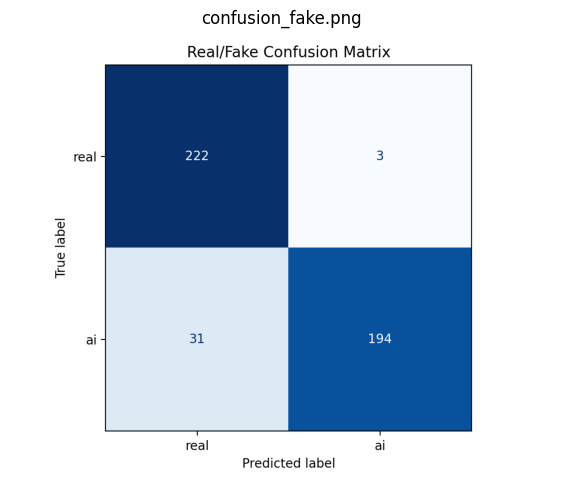

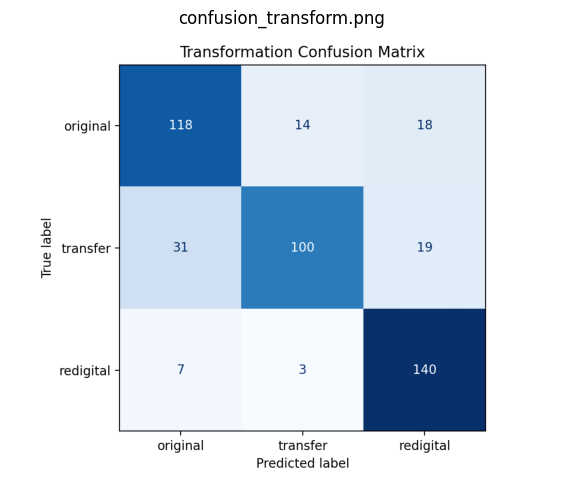

In [37]:
# Show saved confusion matrices if they exist.
for filename in ['confusion_fake.png', 'confusion_transform.png']:
    path = Path(OUTPUT_DIR) / filename
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(7, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(filename)
        plt.show()
    else:
        print(f'Missing: {path}')
